## ⚡ Semiconductor Test Result Prediction

Given *data about semiconductors*, let's try to predict whether a given semiconductor will **pass or fail** a QA test.

We will use a logistic regression model to make our predictions.

Data source: https://www.kaggle.com/datasets/paresh2047/uci-semcom

### Importing Libraries

In [5]:
import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler, SMOTE

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings(action='ignore')
pd.set_option('display.max_columns', None)

In [6]:
data = pd.read_csv('archive/uci-secom.csv')
data

,Time,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,70.0,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,1.0,624.3145,218.3174,0.0,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,1.0,608.1700,84.0793,NaN,NaN,0.0,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.0,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,0.0,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,0.0,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,0.0,0.0,20.95,0.333,12.49,16.713,0.0803,5.72,0.0,11.19,65.363,0.0,0.0,0.0,0.0,0.0,0.0,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.0400,16.230,0.2951,8.64,0.0,10.30,97.314,0.0,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0,0.0744,0.0546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0027,0.0040,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0,0.0,0.0,0.0,0.0,0

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


### Preprocessing

In [8]:
df = data.copy()

In [9]:
# Drop Time
df = df.drop("Time", axis=1)

In [14]:
# Drop columns with more than 25% missing values
missing_value_columns = df.columns[df.isna().mean() > 0.25]
df = df.drop(missing_value_columns, axis=1)

In [16]:
(df.isna().mean() > 0.25).sum()

np.int64(0)

In [17]:
df['Pass/Fail'].isna().sum()

np.int64(0)

In [18]:
# Fill remaining missing values
for column in df.columns:
    df[column] = df[column].fillna(df[column].mean())

In [22]:
("Total missing values: {}".format(df.isna().sum().sum()))

'Total missing values: 0'

In [33]:
(pd.Series({column: len(df[column].unique()) for column in df.columns}) == 1).sum()

np.int64(116)

In [38]:
single_value_columns = df.columns[(pd.Series({column: len(df[column].unique()) for column in df.columns}) == 1)]
single_value_columns

Index(['5', '13', '42', '49', '52', '69', '97', '141', '149', '178',
       ...
       '529', '530', '531', '532', '533', '534', '535', '536', '537', '538'],
      dtype='str', length=116)

In [39]:
# Remove columns with only one value
df = df.drop(single_value_columns, axis=1)

In [23]:
# Give text labels to training examples
df['Pass/Fail'] = df['Pass/Fail'].replace({-1:'PASS', 1: 'FAIL'})

In [40]:
# Split df into X and y
y = df['Pass/Fail'].copy()
X = df.drop('Pass/Fail', axis=1).copy()

In [41]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)

In [42]:
X_train

,0,1,2,3,4,6,7,8,9,10,11,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,46,47,48,50,51,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,70,71,74,75,76,77,78,79,80,81,82,83,84,86,87,88,89,90,91,92,93,94,95,96,98,99,100,101,102,103,104,105,106,107,108,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,142,143,144,145,146,147,148,150,151,152,153,154,155,156,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,180,181,182,183,184,185,187,188,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,221,222,223,224,225,227,228,238,239,248,249,250,251,252,253,254,255,267,268,269,270,271,272,273,274,275,277,278,279,280,281,282,283,285,286,287,288,289,290,291,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,316,317,318,319,320,321,323,324,331,332,333,334,335,336,337,338,339,340,341,342,343,344,347,348,349,350,351,352,353,354,355,356,357,359,360,361,362,363,365,366,367,368,376,377,386,387,388,389,390,391,392,393,405,406,407,408,409,410,411,412,413,415,416,417,418,419,420,421,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,452,453,454,455,456,457,459,460,467,468,469,470,471,472,473,474,475,476,477,478,479,480,482,483,484,485,486,487,488,489,490,491,493,494,495,496,497,499,500,510,511,520,521,522,523,524,525,526,527,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,582,583,584,585,586,587,588,589
390,2989.82,2434.00,2180.0556,1031.0669,0.7565,104.7056,0.1226,1.5865,0.0080,-0.0216,0.9751,201.8822,7.9191,416.1765,9.5523,0.9731,192.3299,12.4480,1.4121,-6894.25,3062.75,-3044.00,1432.7500,0.9823,1.8998,5.1925,69.3111,2.7111,0.1841,4.6913,85.5983,8.5232,50.4559,64.0577,49.5441,66.2289,86.6814,118.5342,78.95,2.607,351.5336,9.7572,142.1773,732.7356,1.0127,131.0882,624.7991,62.1495,4.598,4.870,2824.0,0.9338,0.9440,4.5389,0.0945,350.0627,10.2754,122.2718,10.3280,19.9055,24.3127,708.4228,1.1265,144.6900,617.0245,92.8739,0.0,-0.0109,-0.0620,0.0029,-0.0010,0.0058,-0.1132,-0.0178,0.0231,6.4008,0.134800,2.3746,0.9708,1850.8192,0.1555,8442.1401,0.0659,-0.0038,-0.0012,-0.0003,0.0001,0.3901,-0.8951,0.0530,0.0002,-0.0004,-0.0657,-0.0063,-0.0007,0.0037,0.0012,0.1437,-0.1013,0.9433,0.0,706.6820,0.9914,59.2033,0.5967,0.9795,6.0753,15.73,4.409,15.80,15.76,1.3470,2.481,0.6808,3.021,-0.2838,0.6834,0.9955,2.3177,1000.5914,37.9160,80.0,183.5,185.7,55.7002,202.2790,0.0922,6.63,0.0042,0.1180,0.1158,0.0480,0.0084,8.8498,3.571,14.157,0.4849,0.0077,8.3972,0.33,0.0447,2016.0,618.0,5964.0,272.0,0.136,0.099,0.227,2.7,1.0,0.051,0.208,0.8849,0.0676,0.3177,0.5148,0.3177,0.7387,0.1568,0.385,25.15,0.911,9.18,29.251,0.0695,13.42,20.57,12.087,0.291,10.29,16.13,0.345,14.19,13.71,10.29,12.616,41.114,0.1724,9.51,0.0,23.76,79.519,0.0,0.0980,0.0501,0.0575,0.1419,0.0815,0.0750,0.1010,0.0942,3.7174,0.003000,0.0747,0.0048,179.0892,0.0227,1160.8999,0.0219,0.0320,0.0030,0.0038,0.0391,0.0,127.0183,0.0005,3.4724,0.0335,0.0033,0.6031,0.0634,9.349,2.8453,21.2352,70.0544,63.0484,19.3893,70.7249,0.0341,2.1993,0.0013,0.0383,0.0280,0.0158,0.0028,2.9420,1.0737,4.6834,0.1391,0.0025,2.8362,0.0877,0.0133,927.6154,256.6598,2565.9564,139.7602,0.0596,0.0407,0.1062,0.7928,0.3551,0.0158,0.0760,0.3620,0.0262,0.1223,0.1938,0.1223,0.3011,0.0617,0.1405,8.6585,0.2843,2.7408,8.8845,0.0291,4.2180,6.6180,3.9042,0.0932,3.2855,5.4999,0.1201,3.9053,9.8389,3.2855,3.6819,11.7880,0.0599,2.7397,0.0,7.0483,24.3524,0.0,0.0318,0.0236,0.0269,0.0650,0.0235,0.0424,0.0478,0.0446,1.2024,0.000900,0.0227,0.0019,53.0310,0.0075,352.8198,0.0071,0.0073,0.0066,0.0054,0.0009,0.0013,0.0145,0.0,39.2566,0.0002,0.9206,0.0118,0.0010,0.1943,0.0219,3.3997,1.1348,3.6495,6.1375,7.6294,2.5550,19.6184,12.1833,6.3320,3.4264,7.4378,0.0000,221.7730,0.8662,4.3836,45.0936,3.4017,5.0762,0.7916,4.

In [43]:
y_train

390     PASS
635     PASS
78      PASS
733     PASS
1262    PASS
        ... 
715     PASS
905     PASS
1096    PASS
235     FAIL
1061    PASS
Name: Pass/Fail, Length: 1096, dtype: object

In [44]:
# Scale X
scaler = StandardScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [55]:
# Examining Class Imbalance
pd.DataFrame(y_train.value_counts()).index

Index(['PASS', 'FAIL'], dtype='object', name='Pass/Fail')

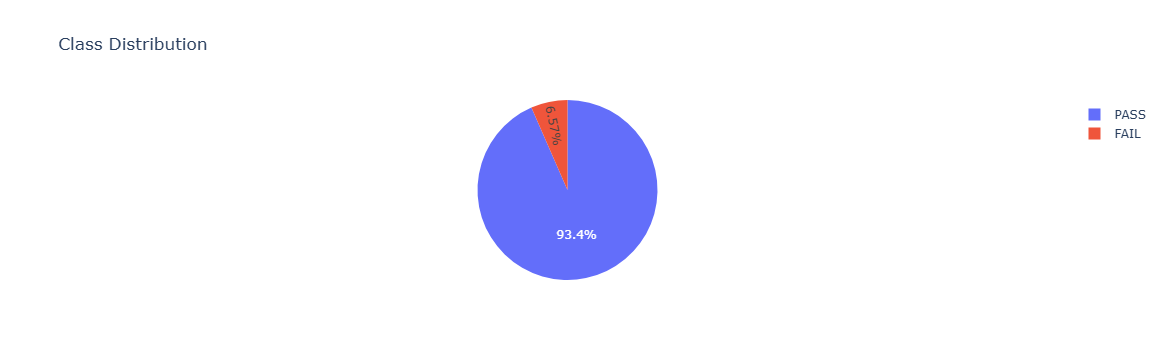

In [56]:
fig = px.pie(
    y_train.value_counts(),
    values='count',
    names= ['PASS', 'FAIL'],
    title = "Class Distribution",
    width = 500
)

fig.show()

### Training a Model (Imbalanced Classes)

In [59]:
def evaluate_model(model, X_test, y_test):
    acc = model.score(X_test, y_test)
    print("Accuracy: {:.2f}%".format(acc * 100))
    
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=['PASS', 'FAIL'])
    clr = classification_report(y_test, y_pred, labels=['PASS', 'FAIL'])

    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False)
    plt.xticks(ticks=[0.5,1.5], labels=['PASS', 'FAIL'])
    plt.yticks(ticks=[0.5,1.5], labels=['PASS', 'FAIL'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("Classification Report:\n------------------------\n", clr)

Accuracy: 88.96%


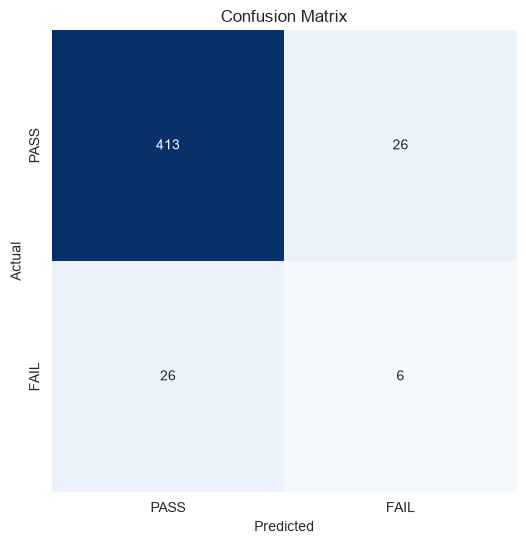

Classification Report:
------------------------
               precision    recall  f1-score   support

        PASS       0.94      0.94      0.94       439
        FAIL       0.19      0.19      0.19        32

    accuracy                           0.89       471
   macro avg       0.56      0.56      0.56       471
weighted avg       0.89      0.89      0.89       471



In [60]:
model = LogisticRegression()
model.fit(X_train, y_train)

evaluate_model(model, X_test, y_test)

#### Random Over Sampling

In [61]:
oversampler = RandomOverSampler(random_state=1)
X_train_os, y_train_os = oversampler.fit_resample(X_train, y_train)

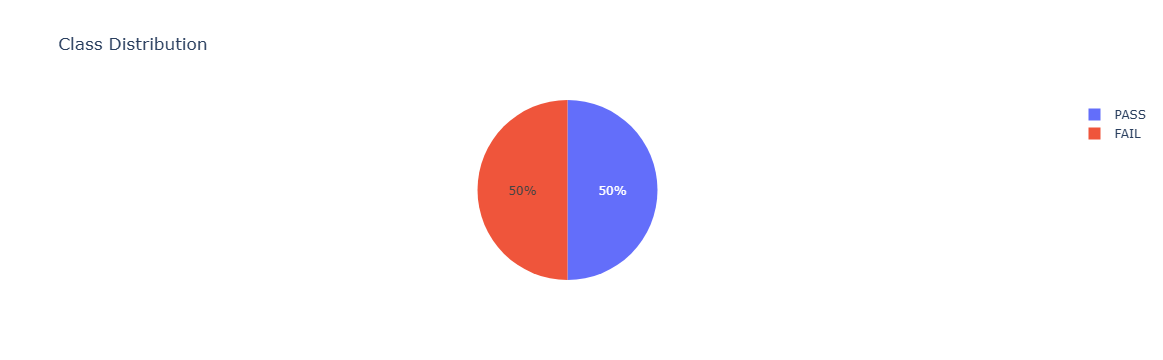

In [62]:
fig = px.pie(
    y_train_os.value_counts(),
    values='count',
    names= ['PASS', 'FAIL'],
    title = "Class Distribution",
    width = 500
)

fig.show()

Accuracy: 86.62%


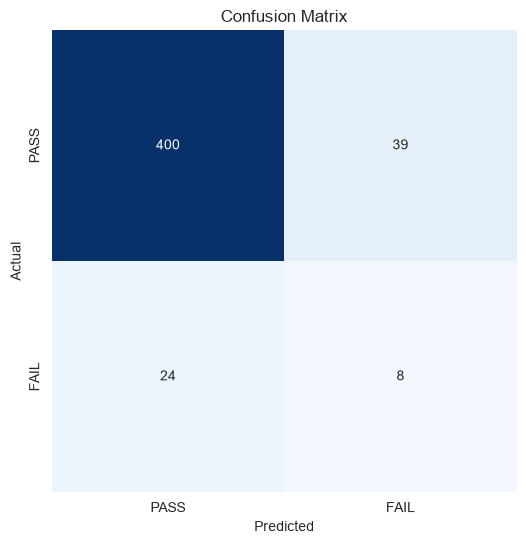

Classification Report:
------------------------
               precision    recall  f1-score   support

        PASS       0.94      0.91      0.93       439
        FAIL       0.17      0.25      0.20        32

    accuracy                           0.87       471
   macro avg       0.56      0.58      0.56       471
weighted avg       0.89      0.87      0.88       471



In [63]:
model = LogisticRegression()
model.fit(X_train_os, y_train_os)

evaluate_model(model, X_test, y_test)

#### Oversampling with SMOTE

In [64]:
oversampler = SMOTE(random_state=1)
X_train_smote, y_train_smote = oversampler.fit_resample(X_train, y_train)

In [65]:
y_train_smote.value_counts()

Pass/Fail
PASS    1024
FAIL    1024
Name: count, dtype: int64

Accuracy: 85.99%


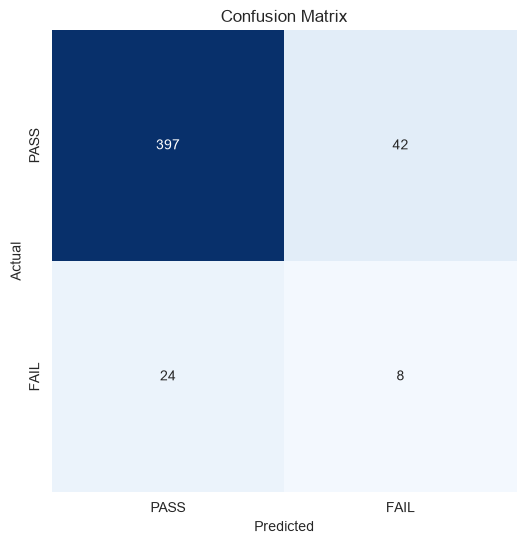

Classification Report:
------------------------
               precision    recall  f1-score   support

        PASS       0.94      0.90      0.92       439
        FAIL       0.16      0.25      0.20        32

    accuracy                           0.86       471
   macro avg       0.55      0.58      0.56       471
weighted avg       0.89      0.86      0.87       471



In [66]:
model = LogisticRegression()
model.fit(X_train_smote, y_train_smote)

evaluate_model(model, X_test, y_test)